In [9]:
# from plot import *
# main(elements.Flags(
#       pattern='**/scores.jsonl',
#       indirs=[''],
#       outdir='',
#       methods='.*',
#       tasks='.*',
#       newstyle=True,
#       indir_prefix=False,
#       workers=16,
#       xkeys=['xs', 'step'],
#       ykeys=['ys', 'episode/score'],
#       ythres=0.0,
#       xlim=0,
#       ylim=0,
#       binsize=0,
#       bins=30,
#       cols=0,
#       legendcols=0,
#       size=[3, 3],
#       xticks=4,
#       yticks=10,
#       stats=['runs', 'auto'],
#       agg=True,
#       todf=''
#   ).parse())

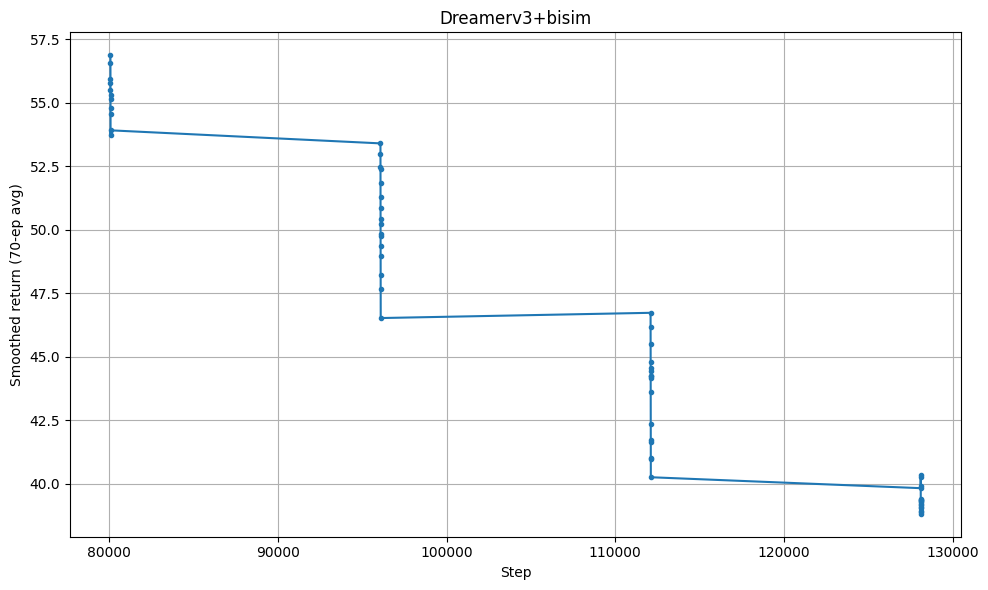

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import os 

# Read gzipped newline-delimited JSON file
path = os.path.expanduser("~/bisim/scores/bisim_dmc_vision-dreamerv3.json.gz")
df = pd.read_json(path,lines=False, compression="gzip")
df["rolling_return"] = df["episode/score"].rolling(window=70).mean()

# Plot step vs episode/score
plt.figure(figsize=(10, 6))
plt.plot(df["step"], df["rolling_return"], marker=".", linestyle="-")
plt.title("Dreamerv3+bisim")
plt.xlabel("Step")
plt.ylabel("Smoothed return (70-ep avg)")
plt.grid(True)
plt.tight_layout()
plt.show()


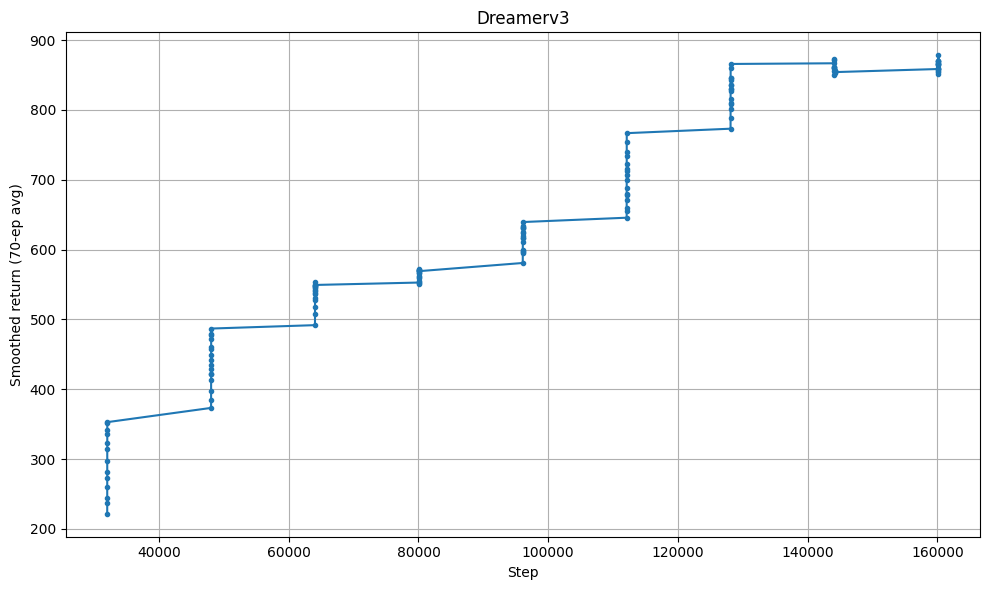

In [44]:
path = os.path.expanduser("~/bisim/scores/baseline_dmc_vision-dreamerv3.jsonl.gz")
df = pd.read_json(path,lines=True, compression="gzip")
df["rolling_return"] = df["episode/score"].rolling(window=20).mean()

# Plot step vs episode/score
plt.figure(figsize=(10, 6))
plt.plot(df["step"], df["rolling_return"], marker=".", linestyle="-")
plt.title("Dreamerv3")
plt.xlabel("Step")
plt.ylabel("Smoothed return (70-ep avg)")
plt.grid(True)
plt.tight_layout()
plt.show()